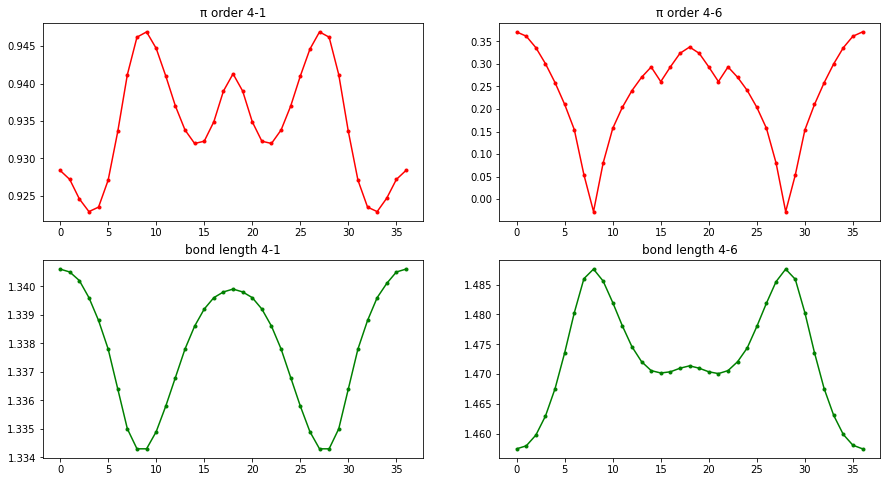

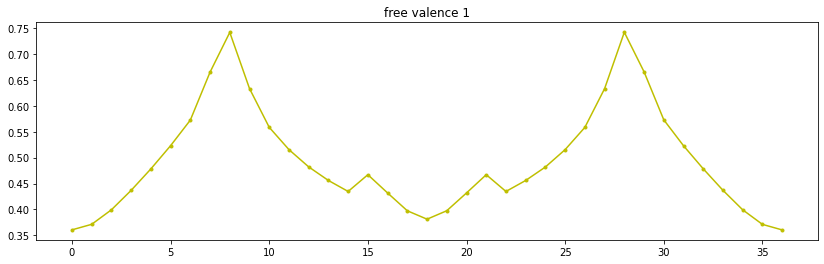

In [1]:
# 联苯键级键角图
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
def get_wfnOrders(atom1,atom2):
    with open(r"C:\code\HFV\files\scan\multiwfnRes.txt",'r',encoding='utf-8') as f:
        data=f.read()
    wfnOrders=re.findall(r'# +\d: +'+f'{atom1}'+'\(C \)    '+f'{atom2}'+'\(C \) +(\d.\d{8})',data)
    wfnOrders=np.array(wfnOrders,dtype=np.float32)
    return wfnOrders
def get_bondOrders(atom1,atom2):
    with open(r"C:\code\HFV\files\scan\RES5.txt",'r',encoding='utf-8') as f:
        data=f.read()
    datas=data.split('----------------------------------------------------------------------')[1:]
    all_res=[]
    all_valence=[]
    for each in datas:
        res=re.search(f'{atom1}->{atom2}'+r',bond order:(-?\d.\d{4}),bond length:(-?\d.\d{4})',each)
        valence=re.search(r'free valence:(-?\d.\d{4})',each).groups()
        if res is not None:
            all_res.append(res.groups())
        else:
            all_res.append([0,0])
        all_valence.append(valence)
    bondOrders=pd.DataFrame(all_res,dtype=float).to_numpy()[:,0]
    bondLengths=pd.DataFrame(all_res,dtype=float).to_numpy()[:,1]
    atomValence=pd.DataFrame(all_valence,dtype=float).to_numpy().flatten()
    return bondOrders,bondLengths,atomValence
fig,a=plt.subplots(2,2,figsize=(15, 8))
center=4
arounds=[1,6]
for i,around in enumerate(arounds):
    bondOrders,bondLengths,atomValence=get_bondOrders(center,around)
    a[0][i].set_title(f'π order {center}-{around}')
    a[0][i].plot(np.arange(len(bondOrders)),bondOrders,'r.-')
    a[1][i].set_title(f'bond length {center}-{around}')
    a[1][i].plot(np.arange(len(bondLengths)),bondLengths,'g.-')
fig,a=plt.subplots(figsize=(14, 4))
a.set_title('free valence 1')
a.plot(np.arange(len(atomValence)),atomValence,'y.-')
# 二面角增加，健级π键减小
# π健级=

In [2]:
bondOrders

array([0.3697, 0.3642, 0.348 , 0.3223, 0.2874, 0.2419, 0.1834, 0.1098,
       0.0309, 0.0394, 0.0983, 0.1472, 0.1882, 0.2234, 0.254 , 0.2817,
       0.307 , 0.3276, 0.3363, 0.3276, 0.307 , 0.2817, 0.2541, 0.2234,
       0.1885, 0.1471, 0.0983, 0.0396, 0.0306, 0.1094, 0.183 , 0.242 ,
       0.2873, 0.3222, 0.3479, 0.3641, 0.3697])

In [6]:
bondOrders

array([0.3711, 0.3656, 0.3494, 0.3236, 0.2886, 0.243 , 0.1842, 0.1102,
       0.031 , 0.0397, 0.0988, 0.148 , 0.1893, 0.2247, 0.2554, 0.2831,
       0.3084, 0.3289, 0.3376, 0.3289, 0.3083, 0.2832, 0.2555, 0.2247,
       0.1896, 0.148 , 0.0989, 0.0398, 0.0307, 0.1098, 0.1838, 0.243 ,
       0.2885, 0.3235, 0.3493, 0.3655, 0.3712])

In [1]:
import numpy as np
a=np.array([1,2,3])
b=a
b[0]=2
a

array([2, 2, 3])

In [10]:
x=np.arange(-2,2)
y=x**2

In [16]:
x0=x[0]+0.1
y0=x0**2
step=1
i=0
while True:
    arounds=x0+np.array([-step,step])
    values=arounds**2
    if min(values)<y0:
        y0=np.min(values)
        minID=np.argmin(values)
        x0=arounds[minID]
        print(i,x0,y0)
        i+=1
    else:
        if step<1e-6:
            print(x0,y0)
            break
        else:
            step/=2


0 -0.8999999999999999 0.8099999999999998
1 0.10000000000000009 0.010000000000000018
2 -0.02499999999999991 0.0006249999999999956
3 0.006250000000000089 3.906250000000111e-05
4 -0.0015624999999999112 2.4414062499997226e-06
5 0.0003906250000000888 1.5258789062506938e-07
6 -9.765624999991118e-05 9.536743164045153e-09
7 2.4414062500088818e-05 5.960464477582431e-10
8 -6.103515624911182e-06 3.725290298353494e-11
9 1.5258789063388178e-06 2.328306436809747e-12
10 -3.8146972647368216e-07 1.4551915221590587e-13
-3.8146972647368216e-07 1.4551915221590587e-13


In [15]:
import numpy as np
a=np.array([
    [1,-1,1,-1],
    [1,1,-1,-1],
    [0,0,0,0]
])
ratios=np.array([1/2**0.5]*4)
normal=np.array([0,1,0])

In [16]:
np.linalg.norm(a,axis=0)*ratios*normal.reshape(3,1)

array([[0., 0., 0., 0.],
       [1., 1., 1., 1.],
       [0., 0., 0., 0.]])

In [14]:
ratios

array([1.41421356, 1.41421356, 1.41421356, 1.41421356])